In [5]:
import numpy as np
import pandas as pd
from scipy.interpolate import BSpline

def generate_bspline_basis(cutoff, degree=3, n_knots=0, 
                           right_constraint=False,  
                           n_points=100):
    # Compute evenly spaced interior knots between 0 and cutoff (excluding endpoints)
    if n_knots > 0:
        interior_knots = np.linspace(0, cutoff, n_knots + 2)[1:-1]
    else:
        interior_knots = []
    k = degree
    # Construct full knot vector with repeated boundary knots (multiplicity k+1)
    t = np.concatenate((
        np.repeat(0.0, k+1),
        interior_knots,
        np.repeat(float(cutoff), k+1)
    ))
    # Number of basis functions before constraints
    n_basis = len(t) - k - 1  # SciPy requires len(t) = n_basis + k + 1:contentReference[oaicite:8]{index=8}
    # Evaluate each basis function on a grid of n_points from 0 to cutoff
    x = np.linspace(0, cutoff, n_points)
    basis_values = []
    for i in range(n_basis):
        coeff = np.zeros(n_basis)
        coeff[i] = 1.0  # coefficient vector to extract the i-th basis function
        spline = BSpline(t, coeff, k, extrapolate=False)
        basis_values.append(spline(x))
    basis_matrix = np.column_stack(basis_values)  # shape: (n_points, n_basis)
    # Apply intercept/right-end constraints by dropping basis columns if requested
    if right_constraint and basis_matrix.shape[1] > 0:
        basis_matrix = basis_matrix[:, :-2]   # drop last basis (constrain right-end behavior)
    # Create DataFrame with x as index
    basis_df = pd.DataFrame(basis_matrix, index=x)
    basis_df.index.name = "x"
    # Label columns for clarity (B1, B2, ...)
    basis_df.columns = [f"B{i+1}" for i in range(basis_df.shape[1])]
    return basis_df


ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.11 from "/usr/bin/python3.11"
  * The NumPy version is: "1.21.5"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: No module named 'numpy.core._multiarray_umath'


In [4]:
! pip install numpy


Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import matplotlib.pyplot as plt

def plot_bspline_basis(basis_df, title="B-spline Basis Functions"):
    plt.figure(figsize=(6,4))
    for col in basis_df.columns:
        plt.plot(basis_df.index, basis_df[col], label=col)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("Basis value")
    plt.legend()
    plt.tight_layout()
    plt.show()



: 

In [ ]:
basis_df = generate_bspline_basis(cutoff=180, degree=3, n_knots=1, 
                                  right_constraint="Right")
print(basis_df.head())  # first few rows of the basis matrix


: 

                B1        B2        B3
x                                     
0.000000  1.000000  0.000000  0.000000
1.818182  0.940610  0.058784  0.000604
3.636364  0.883619  0.113981  0.002383
5.454545  0.828978  0.165679  0.005287
7.272727  0.776638  0.213963  0.009267


ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

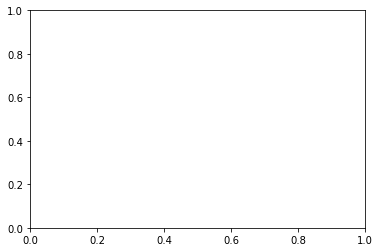

In [16]:
plot_bspline_basis(basis_df, title="Cubic B-spline basis with 3 interior knots")

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_spline_combination(basis_df, coeffs, show_components=True, title="Spline Combination"):
    """
    Plot a weighted sum of B-spline basis functions.

    Parameters:
    - basis_df: pandas DataFrame of basis functions (index = x values)
    - coeffs: list or array of coefficients (must match number of basis columns)
    - show_components: if True, also plot individual weighted components
    - title: title of the plot
    """
    if not isinstance(basis_df, pd.DataFrame):
        raise ValueError("basis_df must be a pandas DataFrame with x-values as index")
    
    if len(coeffs) != basis_df.shape[1]:
        raise ValueError(f"Expected {basis_df.shape[1]} coefficients, got {len(coeffs)}.")

    x = basis_df.index.values
    coeffs = np.array(coeffs)
    weighted_sum = basis_df.values @ coeffs  # Linear combination

    plt.figure(figsize=(8, 5))
    plt.plot(x, weighted_sum, label="Weighted Spline", linewidth=2, color="black")

    if show_components:
        for i, col in enumerate(basis_df.columns):
            plt.plot(x, coeffs[i] * basis_df[col], '--', label=f"{coeffs[i]:.2f} × {col}")

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("Weighted Sum")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

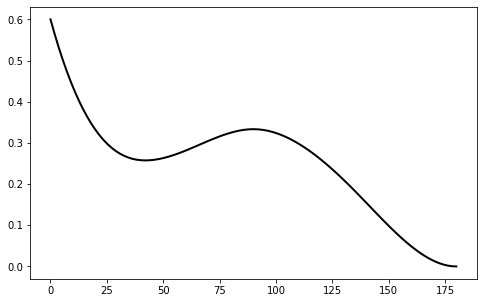

In [18]:
# Generate B-spline basis
basis = generate_bspline_basis(
    cutoff=180,
    degree=3,
    n_knots=3,
    right_constraint=True,
)

# Provide coefficients (must match basis.shape[1])
coeffs = [0.6,0.3, 0.2, 0.4,0.2]

# Plot combination
plot_spline_combination(basis, coeffs, title="WCE-style Weighted Spline")
